In [1]:
import cleanup
import plotting
import stat_analysis
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst
import framewise_stats
import bootstrapping

pd.options.mode.use_inf_as_na = True

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_10784\315590360.py:21: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [2]:
#Loading up dataset 1

tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df_old = cleanup.data_to_dataframe(filepath)

primary_df_old = primary_df_old[primary_df_old['Frame']<600]
primary_df_old = cleanup.calculate_distance_from_fixed_point(primary_df_old)
primary_df_old = cleanup.categorize_values(primary_df_old, 'X', 14, 1.5)

primary_df_old_interp = cleanup.interpolate_missing_values(primary_df_old)
primary_df_old_interp = cleanup.calculate_distance_from_fixed_point(primary_df_old_interp)

In [4]:
# Loading up dataset 2 

tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df_new = cleanup.data_to_dataframe(filepath)

primary_df_new = primary_df_new[primary_df_new['Frame']<600]
primary_df_new = cleanup.calculate_distance_from_fixed_point(primary_df_new)
primary_df_new = cleanup.categorize_values(primary_df_new, 'X', 14, 1.5)

primary_df_new_interp = cleanup.interpolate_missing_values(primary_df_new)
primary_df_new_interp = cleanup.calculate_distance_from_fixed_point(primary_df_new_interp)

KeyError: 'Frame'

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2666: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2666: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2666: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locat

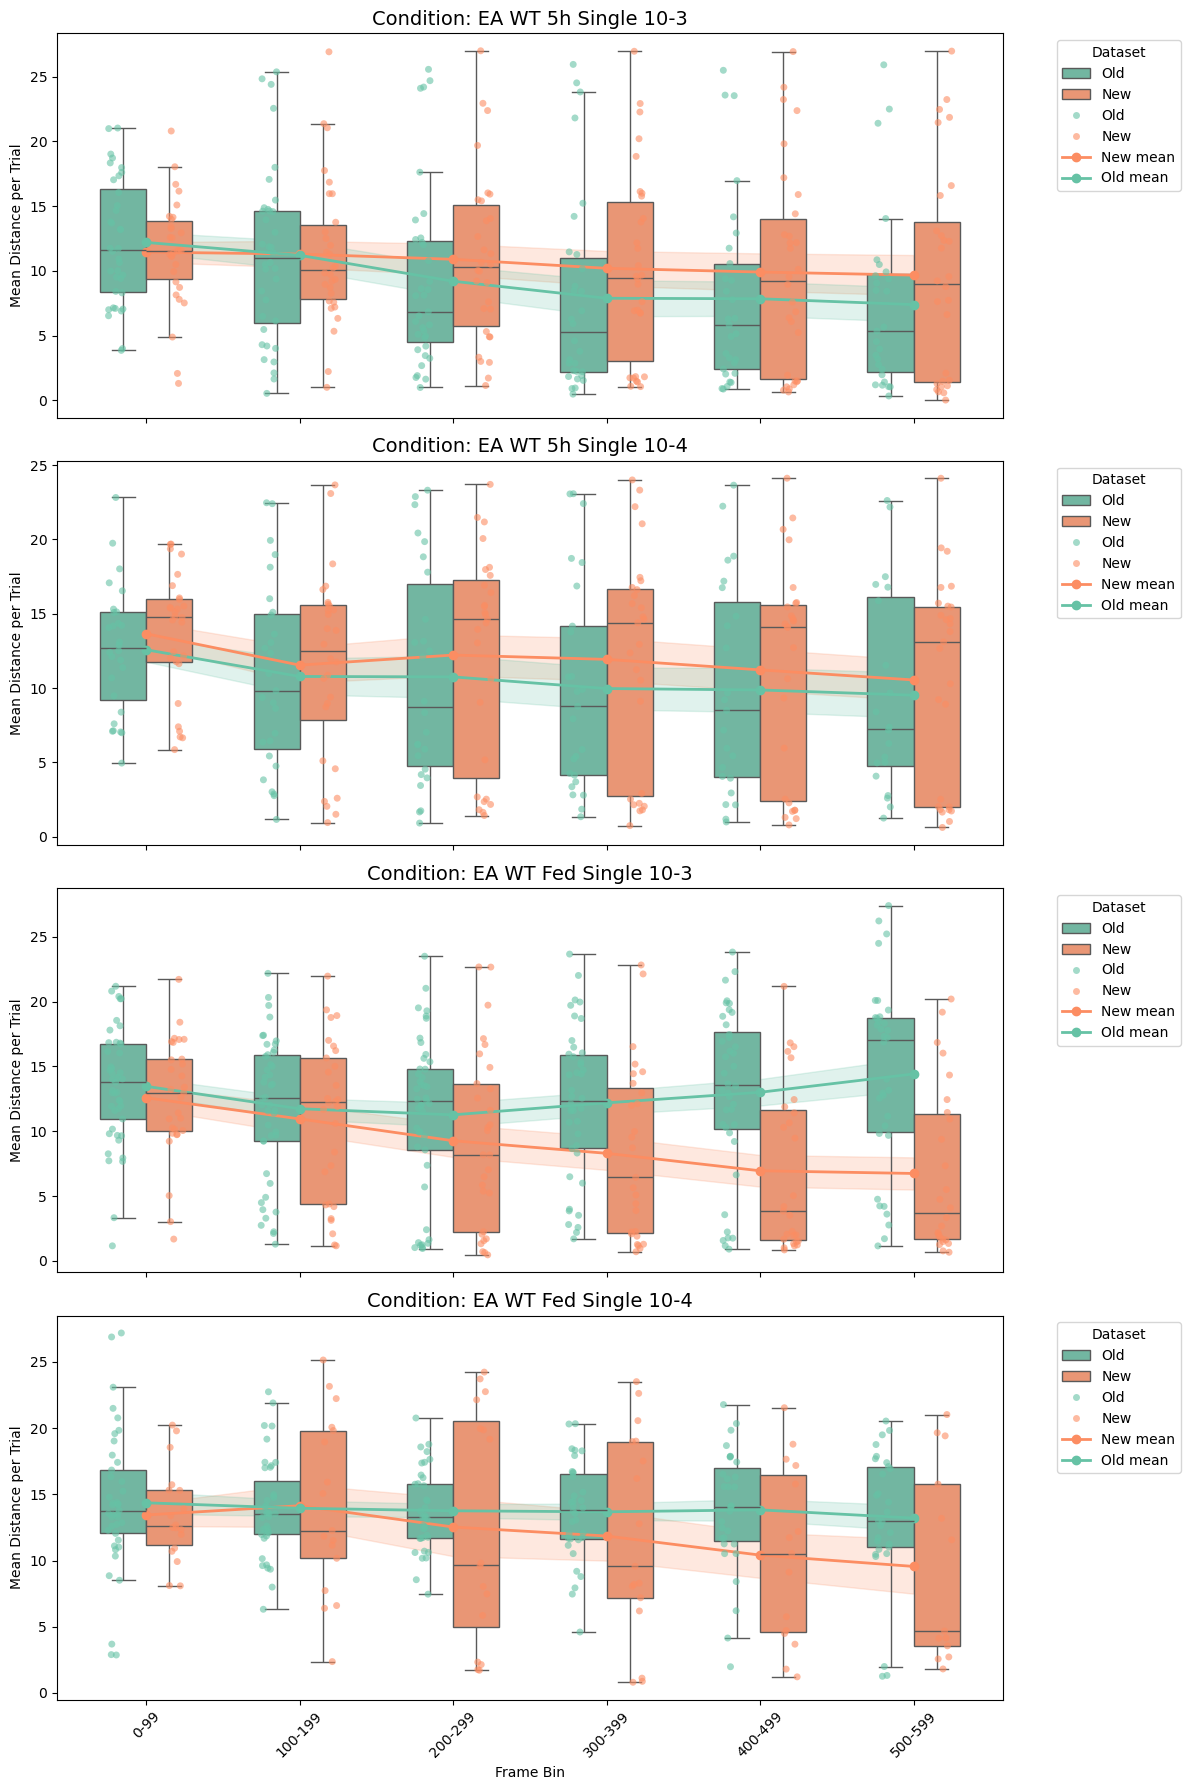

In [20]:
plotting.plot_distance_comparison_collapsed_with_summary(primary_df_old_interp, primary_df_new_interp, dataset_labels=("Old", "New"), plot_type='both')

In [67]:
# Loading up pooled dataset 

tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df_pooled = cleanup.data_to_dataframe(filepath)

primary_df_pooled = primary_df_pooled[primary_df_pooled['Frame']<600]
primary_df_pooled = cleanup.calculate_distance_from_fixed_point(primary_df_pooled)
primary_df_pooled = cleanup.categorize_values(primary_df_pooled, 'X', 14, 1.5)

primary_df_pooled_interp = cleanup.interpolate_missing_values(primary_df_pooled)
primary_df_pooled_interp = cleanup.calculate_distance_from_fixed_point(primary_df_pooled_interp)

(<Figure size 3600x400 with 9 Axes>,
                     Condition  n_steps         R            Z    p_rayleigh  \
 0   EA CSDxTNTe 5h Group 10-4     5304  0.099932    52.967374  8.732102e-24   
 1  EA CSDxTNTe Fed Group 10-4     1978  0.174603    60.302003  4.188005e-27   
 2   EA CSDxTNTi 5h Group 10-4     3060  0.839728  2157.740156  0.000000e+00   
 3  EA CSDxTNTi Fed Group 10-4     1845  0.144012    38.264365  1.994203e-17   
 4   EA TrhxTNTe 5h Group 10-4     5598  0.100070    56.058158  3.938251e-25   
 5  EA TrhxTNTe Fed Group 10-4     1377  0.044737     2.755916  6.352674e-02   
 6   EA TrhxTNTi 5h Group 10-4     5938  0.194819   225.374321  1.430287e-98   
 7  EA TrhxTNTi Fed Group 10-4     2400  0.105886    26.908529  1.919903e-12   
 8                        TRex     3000  0.139453    58.341098  3.499238e-26   
 
    mean_angle_diff_rad  mean_approach_vel  prop_steps_toward  
 0            -2.710378          -0.031069           0.429487  
 1            -3.046430          

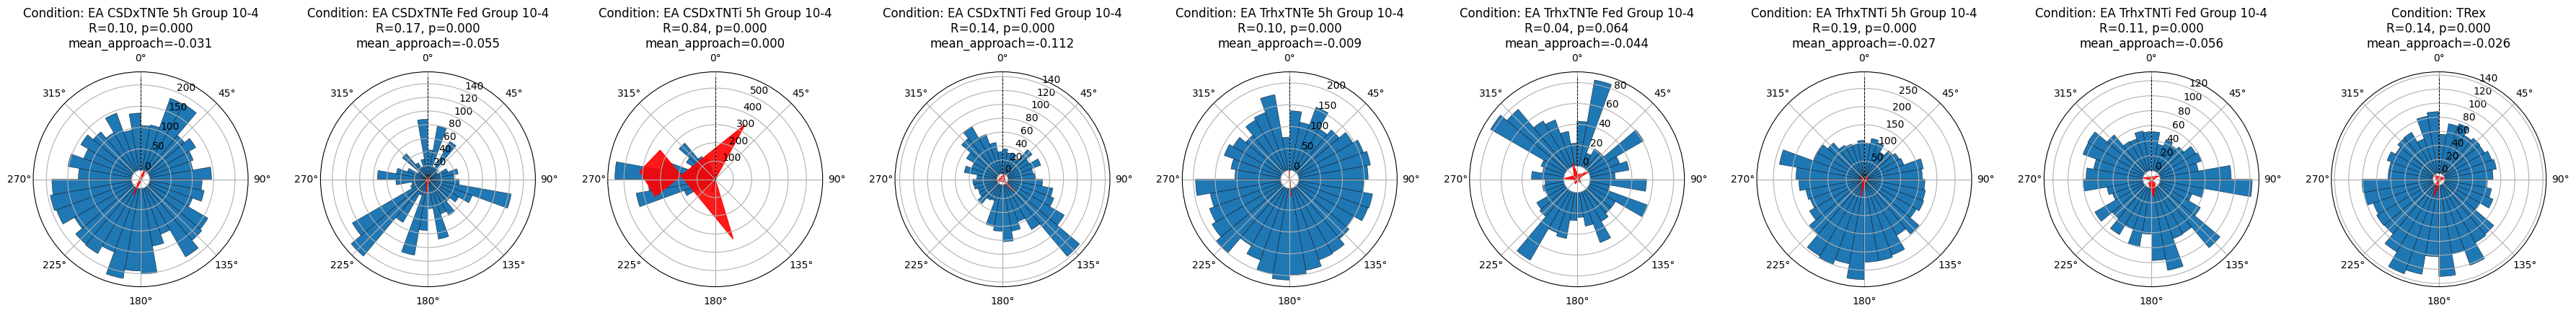

In [68]:
import velocity_analysis
velocity_analysis.plot_odor_attraction_rose(primary_df_pooled_interp, frame_range=(50,100))

In [69]:
# primary_df_pooled_interp_wt = primary_df_pooled_interp[(primary_df_pooled_interp['Condition'] == '10-3') |
#                                                        (primary_df_pooled_interp['Condition'] == '10-4') |
#                                                        (primary_df_pooled_interp['Condition'] == '10-5') |
#                                                        (primary_df_pooled_interp['Condition'] == '5h 10-3') |
#                                                        (primary_df_pooled_interp['Condition'] == '5h 10-4') |
#                                                        (primary_df_pooled_interp['Condition'] == '5h 10-5')]

csd_df = primary_df_pooled_interp[(primary_df_pooled_interp['Genotype'] == 'CSDxTNTe') | (primary_df_pooled_interp['Genotype'] == 'CSDxTNTi')]
trh_df = primary_df_pooled_interp[(primary_df_pooled_interp['Genotype'] == 'TrhxTNTe') | (primary_df_pooled_interp['Genotype'] == 'TrhxTNTi')]

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\plotting.py:3105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
d:\Experiment Work\larva-locater Repo\larva-locater\Structured\plotting.py:3117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


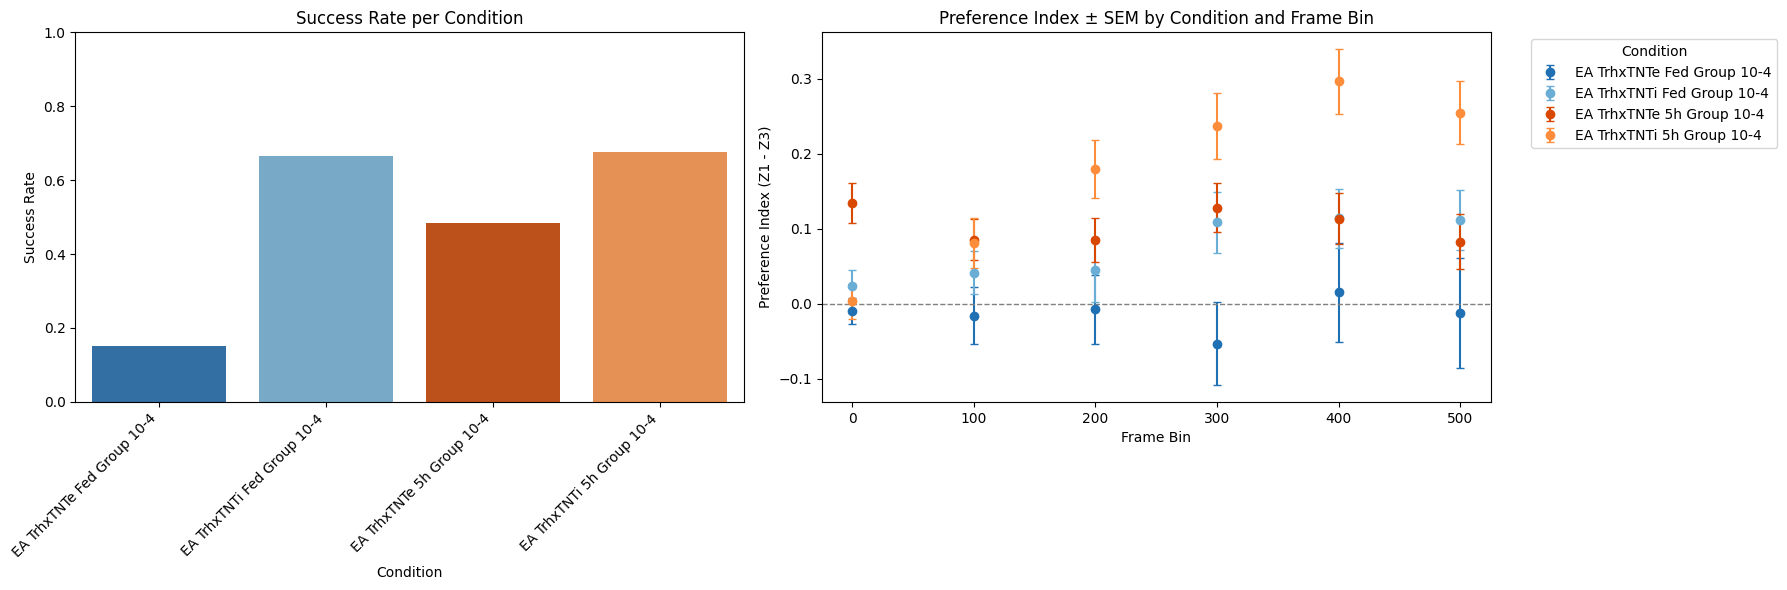

In [42]:
plotting.plot_prefindex_and_successrate_combined(trh_df)

In [ ]:
plotting.plot_prefindex_and_successrate_combined(trh_df)

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\plotting.py:3105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
d:\Experiment Work\larva-locater Repo\larva-locater\Structured\plotting.py:3117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


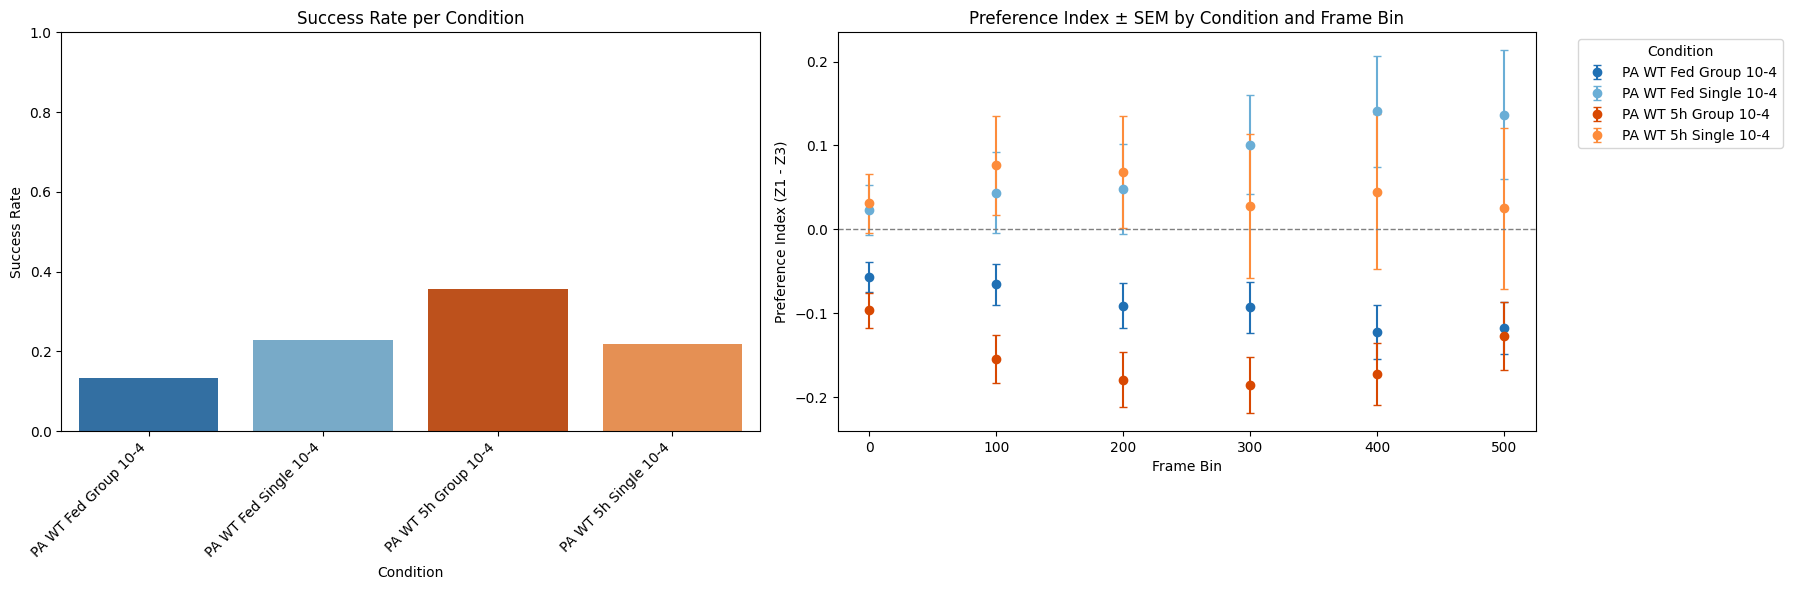

In [62]:
plotting.plot_prefindex_and_successrate_combined(primary_df_pooled_interp[primary_df_pooled_interp['Concentration'] == '10-4'])

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\velocity_analysis.py:202: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_success = g.apply(
d:\Experiment Work\larva-locater Repo\larva-locater\Structured\velocity_analysis.py:209: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_r = g.apply(
d:\Experiment Work\larva-locater Repo\larva-locater\Structured\velocity_analysis.py:202: FutureWarning: Da

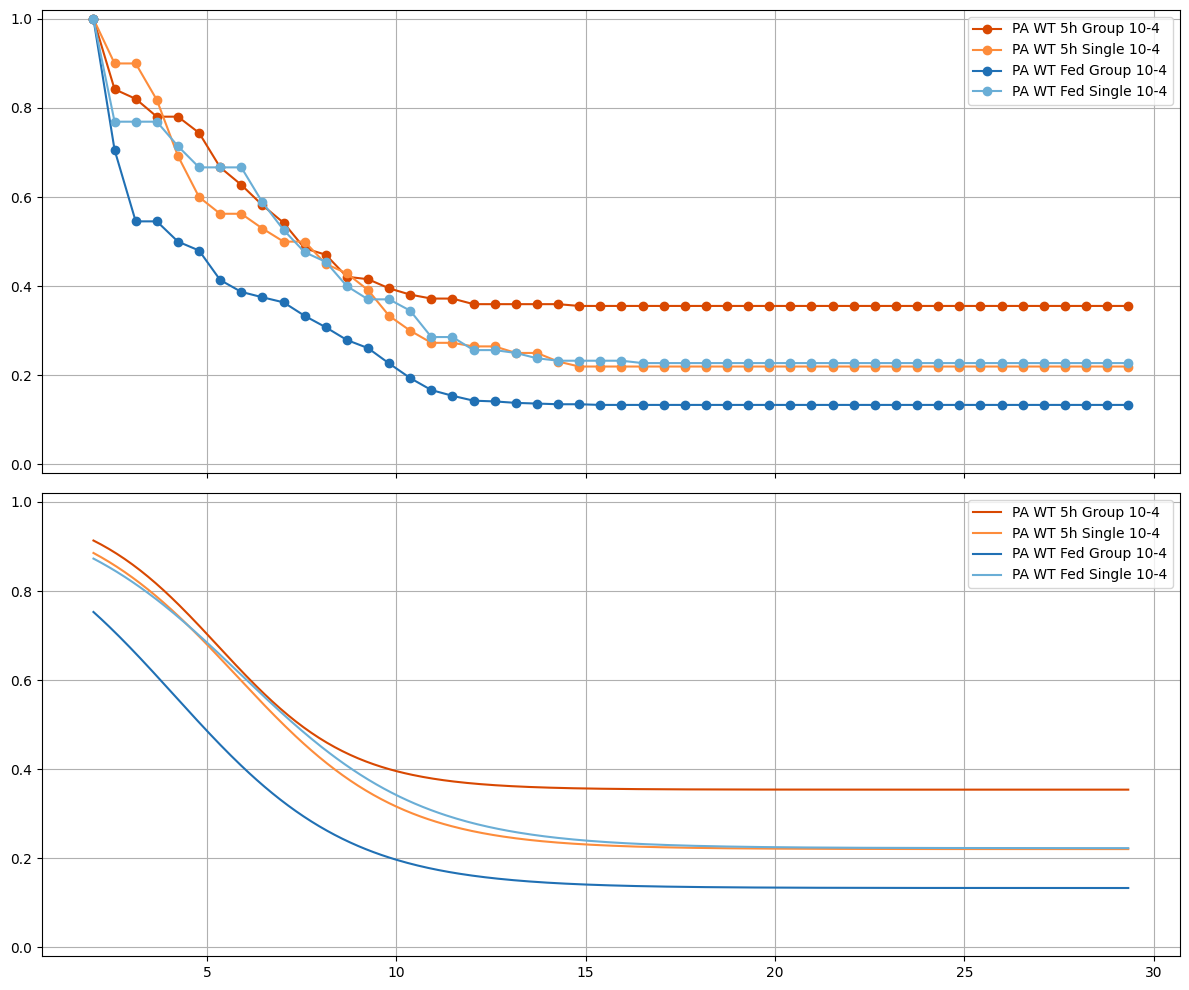

In [63]:
res = velocity_analysis.plot_probability_and_bootstrap_logistic(
    df=primary_df_pooled_interp[primary_df_pooled_interp['Concentration'] == '10-4'],
    target_x=14,
    target_y=2,
    success_radius=2,
    radius_steps=None,
    condition_col='Condition',
    concentration_col='Concentration',
    n_boot=500,           # increase to 1000+ if you want more stable CIs (slower)
    ci=95,
    save_csv=False,
    csv_path="/mnt/data/logistic_params_bootstrap.csv",
    random_state=42
)

In [10]:
comparison_table = res['comparison_table']
print(comparison_table)

               Condition                A                L                k  \
0    PA WT 5h Group 10-4  0.354 +/- 0.002  1.000 +/- 0.069  0.568 +/- 0.099   
1   PA WT 5h Single 10-4  0.221 +/- 0.006  1.000 +/- 0.000  0.466 +/- 0.086   
2   PA WT Fed Group 10-3  0.346 +/- 0.006  1.000 +/- 0.000  0.431 +/- 0.097   
3   PA WT Fed Group 10-4  0.133 +/- 0.008  1.000 +/- 0.217  0.432 +/- 0.159   
4  PA WT Fed Single 10-4  0.223 +/- 0.003  1.000 +/- 0.099  0.418 +/- 0.094   

                r0     R2  
0  5.286 +/- 0.529  0.990  
1  5.774 +/- 0.459  0.976  
2  5.207 +/- 0.532  0.971  
3  4.128 +/- 1.807  0.940  
4  5.908 +/- 0.854  0.983  


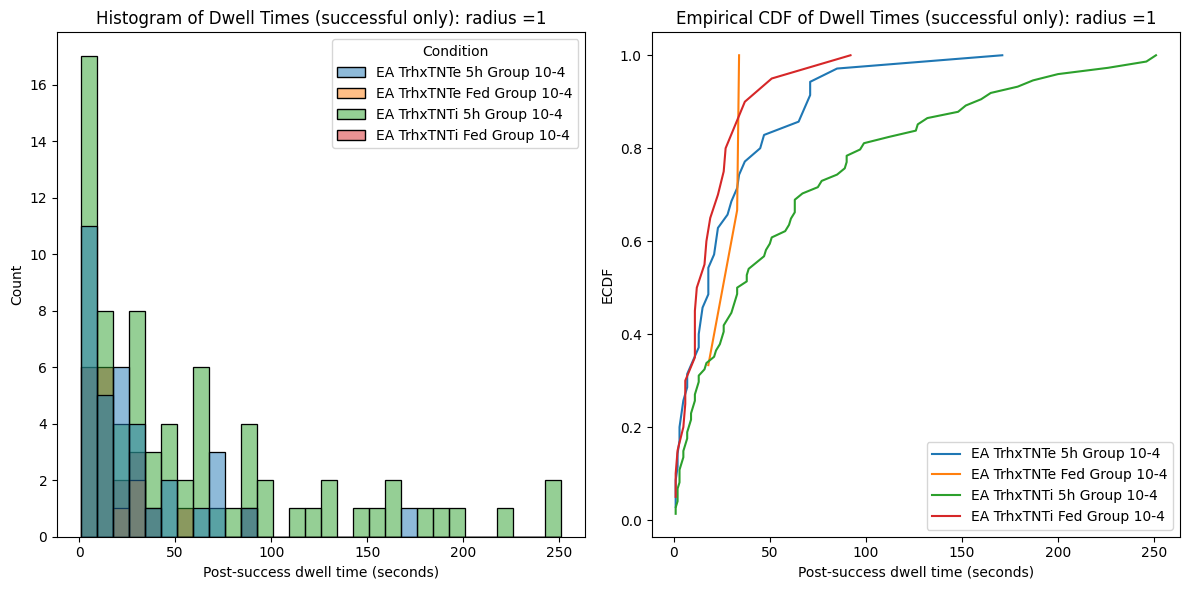

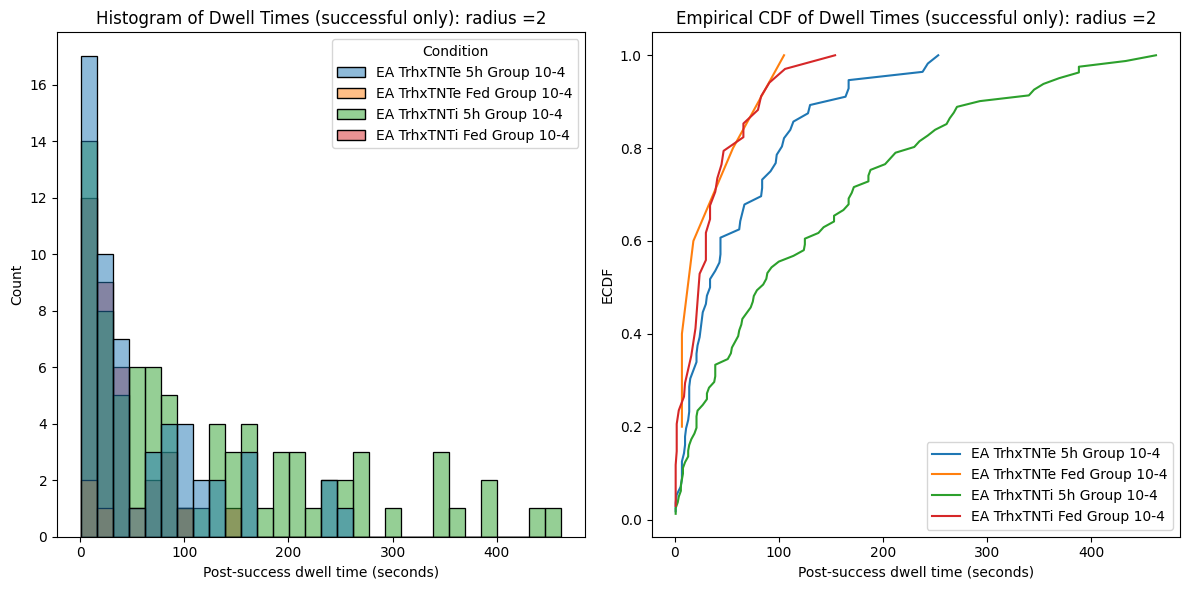

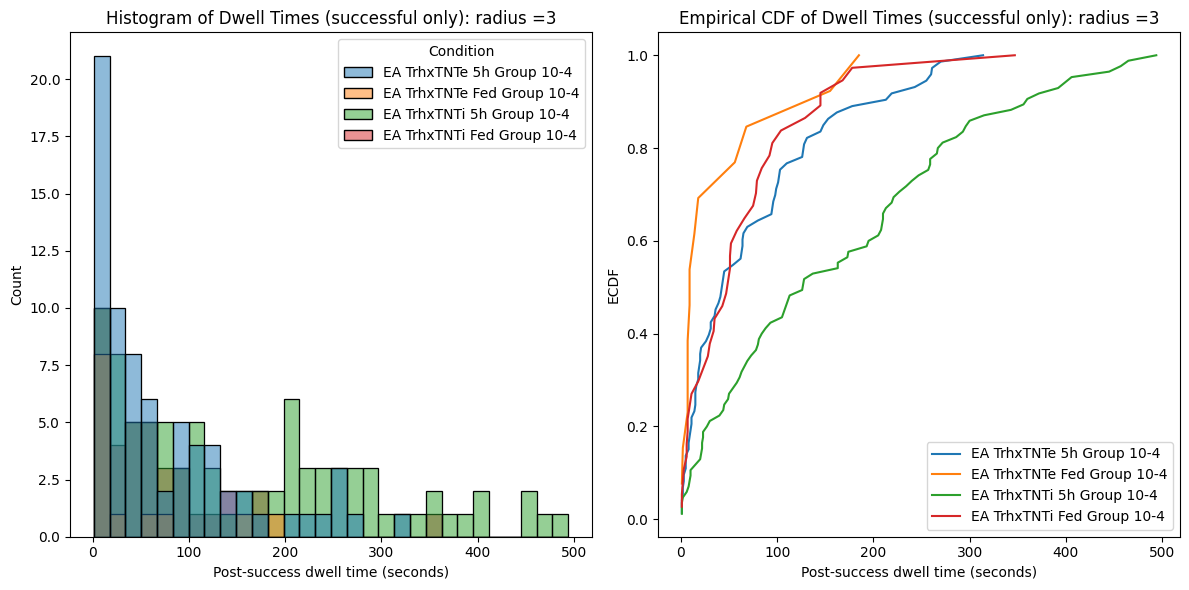

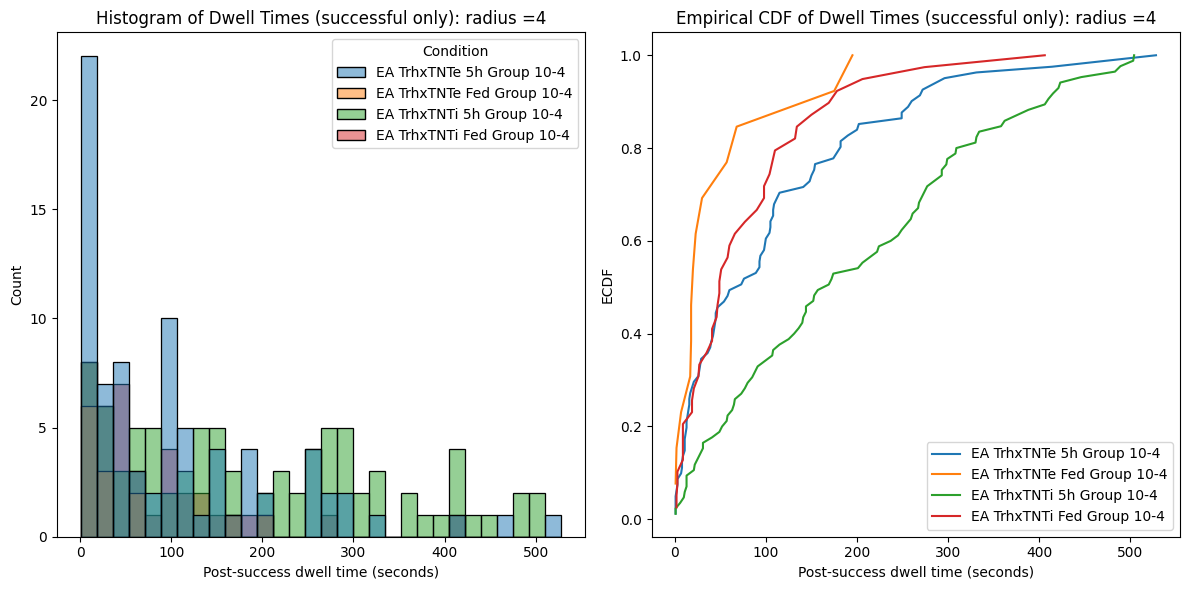

In [71]:
for n in (1, 2, 3, 4):
    res = velocity_analysis.plot_post_success_dwell_total_filtered(
        df=trh_df,
        target_x=14,
        target_y=2,
        success_radius=n,
        condition_col='Condition',
    )